House price prediction using python 


In [2]:
import pandas as pd

first we should import the dataset 

df = pd.read_csv("C:\Users\gulizar_elhalil\OneDrive\Desktop\house_price_prediction\house_prices_practice.csv")

In [3]:
df = pd.read_csv("C:/Users/gulizar_elhalil/OneDrive/Desktop/house_price_prediction/house_prices_practice.csv")
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


###info about the dataset:
 The data is provided in CSV format and includes key numerical features such as overall quality, living area, garage capacity, basement size, year built, number of rooms, and lot area. The target variable SalePrice is generated using realistic relationships between features, making the dataset suitable for EDA, feature engineering, regression modeling, and performance evaluation. The dataset is clean, beginner-friendly, and ready to use without preprocessing.

In [4]:
#understanding the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [5]:
df.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [6]:
df.describe(include = "all")

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [7]:
df.shape

(300, 10)

In [8]:
#cleaning the data
df.isnull().sum()              # check missing values
df = df.drop_duplicates()      # remove duplicates
df.fillna(df.mean(), inplace=True)       # fill missing numeric values

In [9]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [10]:
df.columns

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')

Analyze the data set after we made the data cleaning 

In [11]:
import seaborn as sns

In [12]:
import matplotlib.pyplot as plt

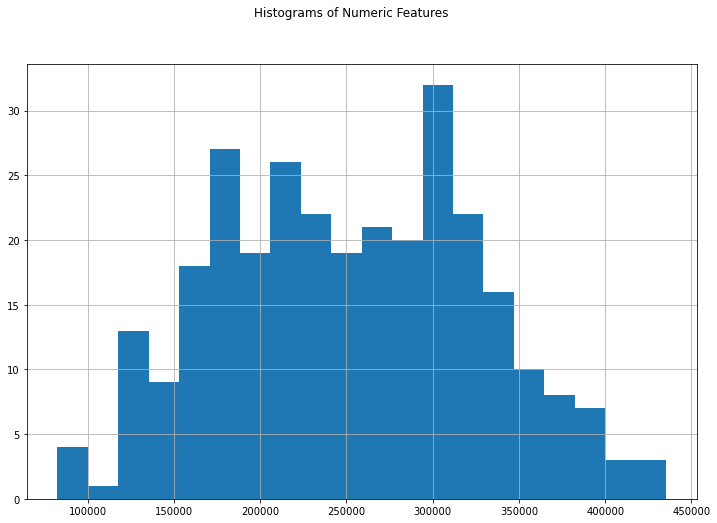

In [13]:
df["SalePrice"].hist(bins=20, figsize=(12, 8))
plt.suptitle("Histograms of Numeric Features")
plt.show()

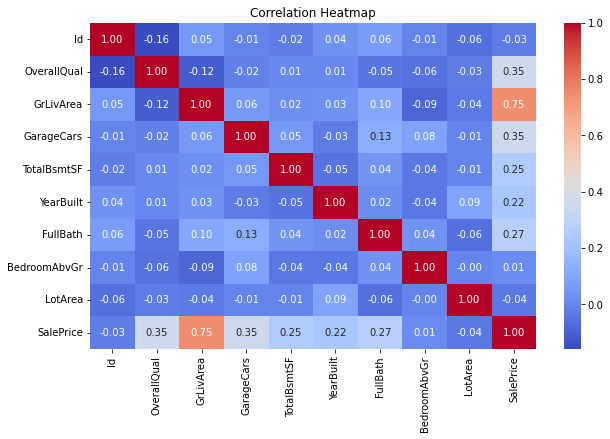

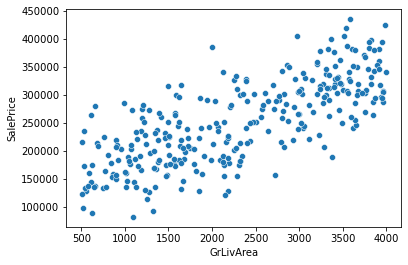

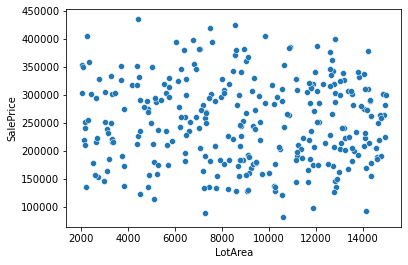

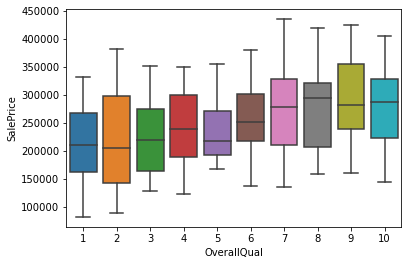

In [14]:
# 5. Bivariate Analysis
#annot=True → Hücrelerin içine sayısal değerleri yazar.
#cmap="coolwarm" → Renk paletini belirler.
#fmt=".2f" → Sayıları iki ondalık basamakla gösterir.
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
# Scatter plots
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.show()

sns.scatterplot(x='LotArea', y='SalePrice', data=df)
plt.show()

# Boxplots for categorical-like features
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.show()

Text(0.5, 1.0, 'House Price vs YearSold')

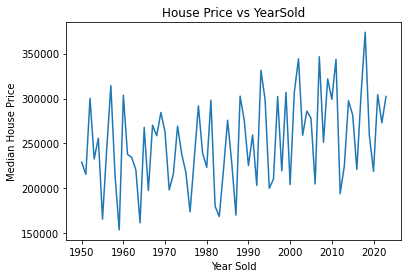

In [15]:
## Lets analyze the Temporal Datetime Variables
## We will check whether there is a relation between year the house is sold and the sales price

df.groupby('YearBuilt')['SalePrice'].median().plot()
plt.xlabel('Year Sold')
plt.ylabel('Median House Price')
plt.title("House Price vs YearSold")

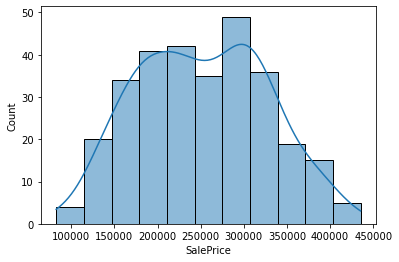

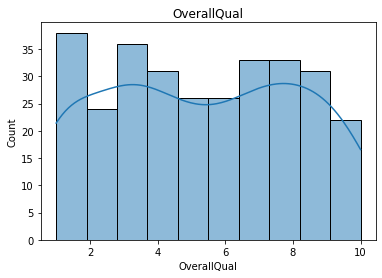

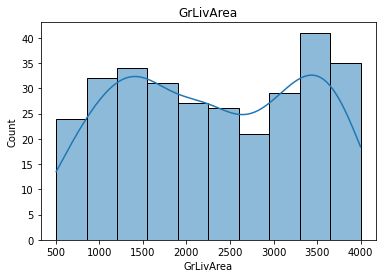

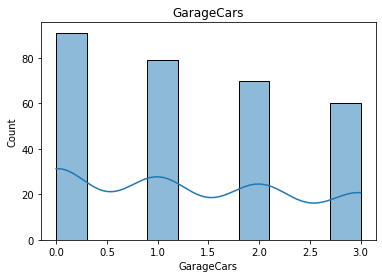

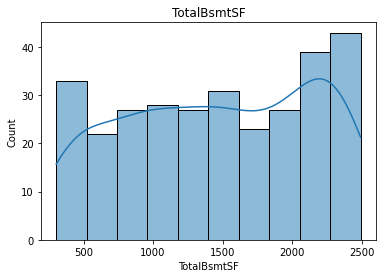

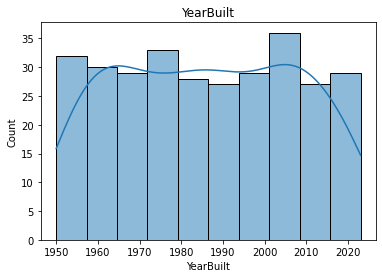

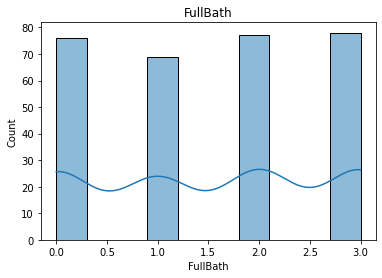

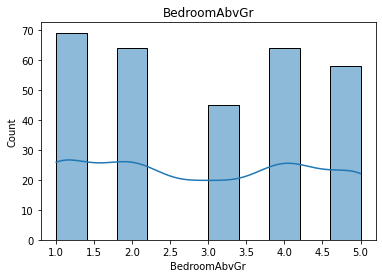

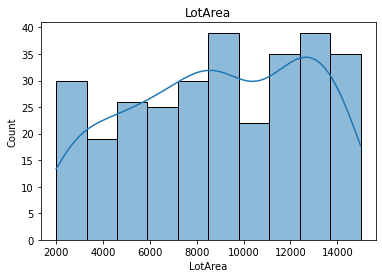

In [16]:
# Target variable distribution
sns.histplot(df['SalePrice'], kde=True)
plt.show()

# Numerical features distributions
num_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea']
for col in num_features:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [17]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['GrLivArea'] < Q1 - 1.5*IQR) | (df['GrLivArea'] > Q3 + 1.5*IQR))]

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df[['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','YearBuilt','FullBath','BedroomAbvGr','LotArea']]
y = df['SalePrice']

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))

Linear Regression R2: 0.9724369952260821
Linear Regression RMSE: 12505.459264618985
Random Forest R2: 0.8679710467264632
Random Forest RMSE: 27369.757897632226


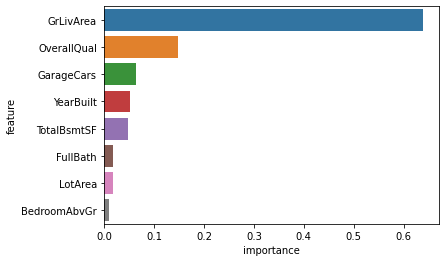

In [20]:
import numpy as np

feature_importances = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.show()

In [21]:
# =========================
# K-Means Clustering
# =========================
from sklearn.cluster import KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
df["Cluster"] = kmeans.fit_predict(X)

In [22]:
print("Inertia:", kmeans.inertia_)

Inertia: 908874951.72605


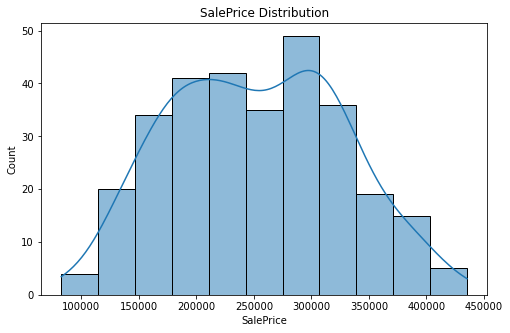

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

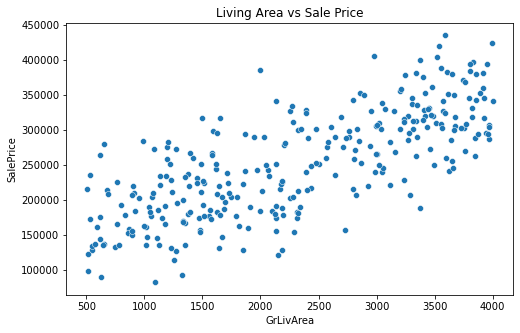

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.title("Living Area vs Sale Price")
plt.show()

In [25]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.8741692286905743


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Prepare the feature matrix X and target vector y
# We drop any columns not required for prediction (if any were to exist besides SalePrice)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred = lr_model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R² Score: {r2:.3f}")
print(f"Mean Squared Error: {mse:.3f}")

# If further refinement is needed, consider cross-validation and hyperparameter tuning

R² Score: 0.971
Mean Squared Error: 166173642.856


Conclusions
This notebook explored the structural characteristics of houses and how they relate to sale prices. Through visualization, we emphasized correlations, distributions, and trends inherent in the data. Our baseline linear regression model provides a window into predictive performance, achieving an R² score that offers insights into model fit.

Our approach balances data exploration and model development. Future analyses could include feature engineering, testing alternative algorithms, and incorporating cross-validation procedures to further tune prediction accuracy. If you found the approach useful, do consider upvoting this notebook.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

2: Loading Data and Initial View
df = pd.read_csv()
3. Data clearning
df.isnull().sum()
df.duplicated().sum()

In [28]:
df.duplicated().sum()

0

Correlation Matrix

Shape of correlation matrix: (11, 11)
Features: ['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice', 'Cluster']


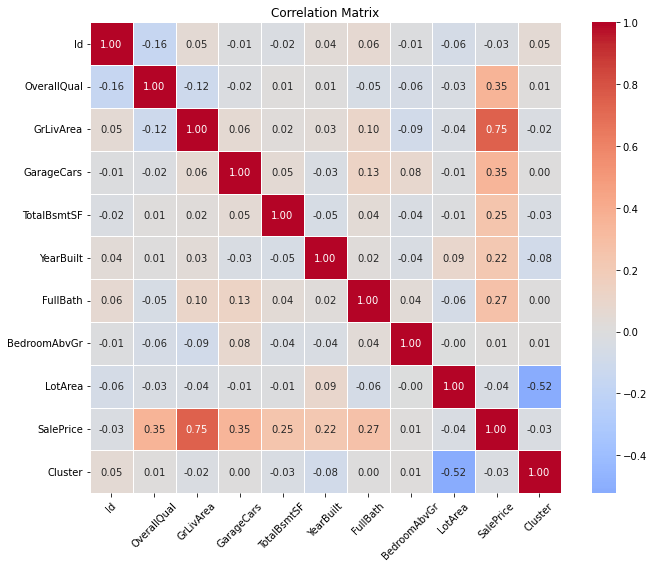

In [48]:
#5. Variable Analysis¶
corr_matrix = df.corr()
print('Correlation Matrix')
print("=" * 60)

# 2. Displaying some statistics
print(f"\nShape of correlation matrix: {corr_matrix.shape}")
print(f"Features: {list(corr_matrix.columns)}")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
# Finding the Highest Correlations with (SalePrice)
correlation_with_target = corr_matrix['SalePrice'].sort_values(ascending=False)
print("=" * 60)
print("Correlation with Sale Price :")
print("=" * 60)
for feature, corr_value in correlation_with_target.items():
    if feature != 'SalePrice':
        print(f"{feature}: {corr_value:.3f}")

Correlation with Sale Price :
GrLivArea: 0.745
OverallQual: 0.353
GarageCars: 0.351
FullBath: 0.274
TotalBsmtSF: 0.250
YearBuilt: 0.222
BedroomAbvGr: 0.014
Id: -0.025
Cluster: -0.028
LotArea: -0.039


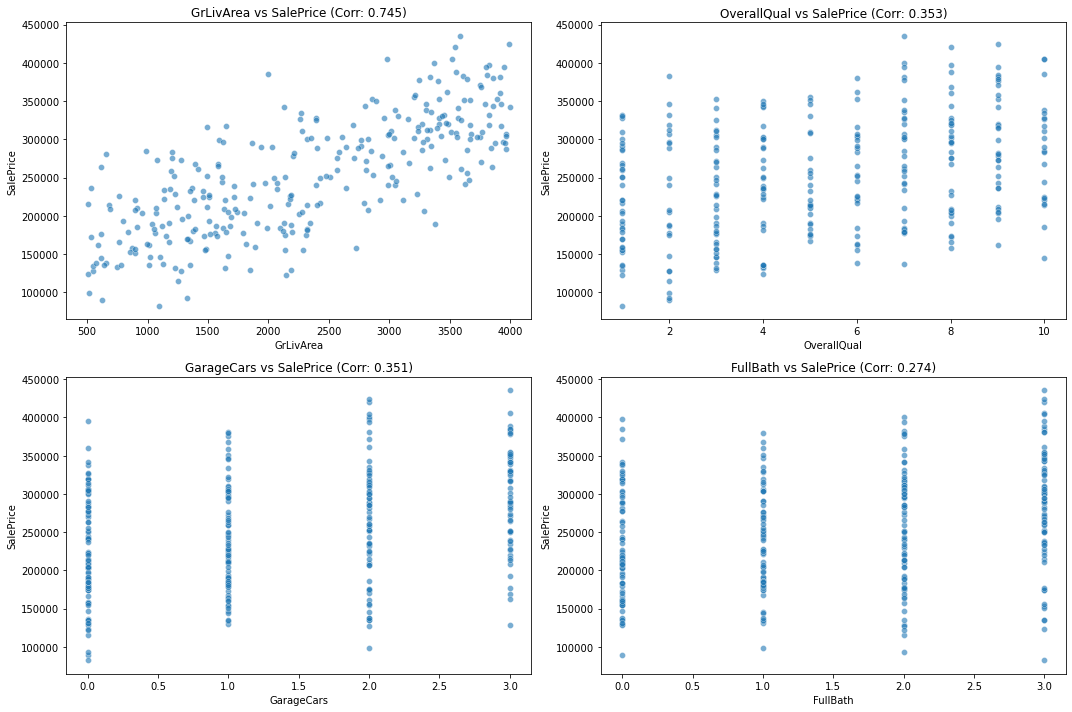

In [50]:
# Depicting the relationships between the four most important variables and the selling price
top_features = correlation_with_target.index[1:5]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=df, x=feature, y='SalePrice', alpha=0.6)
    plt.title(f'{feature} vs SalePrice (Corr: {corr_matrix.loc[feature, "SalePrice"]:.3f})')
    plt.xlabel(feature)
    plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()

Data Exploration Notes:¶
Dataset Overview: Dataset contains 300 records and 10 columns

All columns are numeric (int64)

No missing values detected in any column

No duplicate rows detected

Statistics:
Data shows realistic house property values

SalePrice ranges from 177,106 to 360,609, showing varied housing prices

YearBuilt ranges from 1969 to 2020, showing historical to recent constructions

LotArea varies significantly (8,059 to 13,530), indicating diverse property sizes

Outlier Detection:
No outliers detected using 3×IQR method across all columns

All features appear to have reasonable distributions without extreme values

Variable Analysis:
Key Correlations with SalePrice:
OverallQual (Overall Quality): Strong positive correlation (most important predictor)

GrLivArea (Above Grade Living Area): Strong positive correlation

GarageCars (Garage Cars Capacity): Positive correlation

TotalBsmtSF (Total Basement Area): Positive correlation

YearBuilt (Construction Year): Positive correlation

In [51]:
#Data Preprosesing
#1. Separate the variables from the target
X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

In [52]:
#2. Splitting the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Training data size: {X_train.shape}")
print(f" Testing data size: {X_test.shape}")

 Training data size: (240, 9)
 Testing data size: (60, 9)


In [53]:
#Building Models¶
#1. Creating a pipeline for measurement and training
pipelines = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'DecisionTree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ])

}

In [54]:
#2. Training and Evaluating Models
print("=" * 60)
print('Model Evaluation Results')
print("=" * 60)

results = {}

for model_name, pipeline in pipelines.items():
    # Training Models
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

   # Metrics Calculation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

    print(f"\n{model_name}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2 Score: {r2:.4f}")

Model Evaluation Results

LinearRegression:
  MAE: 10615.80
  MSE: 166247419.24
  RMSE: 12893.70
  R2 Score: 0.9707

DecisionTree:
  MAE: 36876.00
  MSE: 2269594280.07
  RMSE: 47640.26
  R2 Score: 0.6000

RandomForest:
  MAE: 21341.53
  MSE: 755896114.01
  RMSE: 27493.56
  R2 Score: 0.8668


In [55]:
# Create a variable for a new house and predict its price
# Define features for a new house (adjust values as needed)
new_house = pd.DataFrame({
    'OverallQual': [8],           # Overall quality (1-10)
    'GrLivArea': [2500],          # Ground living area (sq ft)
    'GarageCars': [2],            # Number of garage cars
    'TotalBsmtSF': [1200],        # Total basement area (sq ft)
    'YearBuilt': [2012],          # Year built
    'FullBath': [2],              # Number of full bathrooms
    'BedroomAbvGr': [4],          # Number of bedrooms above ground
    'LotArea': [10000],           # Total lot area (sq ft)
    'Cluster': [0]                # Cluster assignment (if using k-means)
})

# Display new house features
print("="*60)
print("New House Features:")
print("="*60)
print(new_house)

# Make predictions using the best model (RandomForest typically performs well)
best_model = pipelines['RandomForest']
predicted_price = best_model.predict(new_house)[0]

print(f"\nPredicted Price for New House: ${predicted_price:,.2f}")

# Optional: Get predictions from all models
print("\n" + "="*60)
print("Predictions from All Models:")
print("="*60)
for model_name, pipeline in pipelines.items():
    price = pipeline.predict(new_house)[0]
    print(f"{model_name}: ${price:,.2f}")

New House Features:
   OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0            8       2500           2         1200       2012         2   

   BedroomAbvGr  LotArea  Cluster  
0             4    10000        0  

Predicted Price for New House: $303,546.94

Predictions from All Models:
LinearRegression: $329,549.83
DecisionTree: $328,413.00
RandomForest: $303,546.94


In [58]:
# Create a variable for a new house and predict its price
# Define features for a new house (adjust values as needed)
new_house = pd.DataFrame({
    'OverallQual': [8],           # Overall quality (1-10)
    'GrLivArea': [2000],          # Ground living area (sq ft)
    'GarageCars': [2],            # Number of garage cars
    'TotalBsmtSF': [1200],        # Total basement area (sq ft)
    'YearBuilt': [2012],          # Year built
    'FullBath': [2],              # Number of full bathrooms
    'BedroomAbvGr': [4],          # Number of bedrooms above ground
    'LotArea': [10000],           # Total lot area (sq ft)
    'Cluster': [0]                # Cluster assignment (if using k-means)
})

# Display new house features
print("="*60)
print("New House Features:")
print("="*60)
print(new_house)

# Make predictions using the best model (RandomForest typically performs well)
best_model = pipelines['RandomForest']
predicted_price = best_model.predict(new_house)[0]

print(f"\nPredicted Price for New House: ${predicted_price:,.2f}")

# Optional: Get predictions from all models
print("\n" + "="*60)
print("Predictions from All Models:")
print("="*60)
for model_name, pipeline in pipelines.items():
    price = pipeline.predict(new_house)[0]
    print(f"{model_name}: ${price:,.2f}")

New House Features:
   OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0            8       2000           2         1200       2012         2   

   BedroomAbvGr  LotArea  Cluster  
0             4    10000        0  

Predicted Price for New House: $267,203.44

Predictions from All Models:
LinearRegression: $301,790.26
DecisionTree: $327,036.00
RandomForest: $267,203.44
